# Feed Forward assignment

"Use an LLM to write a PyTorch program to be handed in in the file feedforwardAssignment.ipynb.
The program should contain a data generation class, a model class implementing for example the
network listed above, a training loop (with mini-batch learning using the PyTorch DataLoader
method and the Adam optimizer), visualization to make plots like Figure 1 for both the training
and a validation set. When making programs with an LLM, it works well to give a short description
of the overall task and then in the back and forth manner break the task into subtasks that each
can be validated independently."

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline


In [3]:
class XORData(Dataset):
    def __init__(self, n_points=300, s=0.1):
        self.n_points = n_points
        self.s = s
        self.data = self.generate_data()

    def generate_data(self):
        m = [(0, 0), (0, 1), (1, 0), (1, 1)]
        data = []
        for _ in range(self.n_points):
            m1, m2 = m[np.random.choice(4)]
            x1 = m1 + self.s * np.random.normal()
            x2 = m2 + self.s * np.random.normal()
            y = m1 ^ m2
            data.append((x1, x2, y))  # Ensure correct tuple structure
        return data


    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x1, x2, y = self.data[idx]
        return torch.tensor([x1, x2], dtype=torch.float32), torch.tensor(y, dtype=torch.float32)


In [4]:
class XORNet(nn.Module):
    def __init__(self):
        super(XORNet, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 3),
            nn.Tanh(),
            nn.Linear(3, 1),
            nn.Identity()
        )
        self.initialize_weights()

    def initialize_weights(self):
        for i, layer in enumerate(self.model):
            if isinstance(layer, nn.Linear):
                # Check the next layer to infer activation function
                next_layer = self.model[i + 1] if i + 1 < len(self.model) else None

                # Match initialization to activation function
                if isinstance(next_layer, nn.Tanh):
                    nn.init.kaiming_uniform_(layer.weight, nonlinearity='tanh')
                elif isinstance(next_layer, nn.ReLU):
                    nn.init.kaiming_uniform_(layer.weight, nonlinearity='relu')
                elif isinstance(next_layer, nn.Sigmoid):
                    nn.init.xavier_uniform_(layer.weight)  # Xavier often works well with sigmoid
                elif isinstance(next_layer, nn.Identity):
                    nn.init.kaiming_uniform_(layer.weight, nonlinearity='linear')  # Identity acts as linear
                else:
                    # Default to Xavier for unknown activations
                    nn.init.xavier_uniform_(layer.weight)

                # Initialize biases to zero
                nn.init.zeros_(layer.bias)


    def forward(self, x):
        return self.model(x)


In [5]:
def plot_data(data, model=None, title=""):
    inputs, labels = zip(*[(x.numpy(), y.numpy()) for x, y in data])  # Unpack inputs and labels
    x = np.array(inputs)
    y = np.array(labels)

    plt.figure(figsize=(8, 6))
    plt.scatter(x[y == 0, 0], x[y == 0, 1], c='green', label='Label 0')
    plt.scatter(x[y == 1, 0], x[y == 1, 1], c='orange', label='Label 1')

    if model:
        xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
        grid = np.c_[xx.ravel(), yy.ravel()]
        grid_tensor = torch.tensor(grid, dtype=torch.float32)
        with torch.no_grad():
            logits = model(grid_tensor)
            preds = torch.sigmoid(logits).numpy().reshape(xx.shape)
        plt.contourf(xx, yy, preds, levels=[0, 0.5, 1], alpha=0.3, cmap='coolwarm')

    plt.title(title)
    plt.legend()
    plt.show()


In [6]:
# Generate dataset
train_data = XORData(n_points=300, s=0.1)
val_data = XORData(n_points=100, s=0.1)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)

Epoch 1, Loss: 6.9322
Epoch 2, Loss: 6.9270
Epoch 3, Loss: 6.9063
Epoch 4, Loss: 6.9007
Epoch 5, Loss: 6.8718
Epoch 6, Loss: 6.8963
Epoch 7, Loss: 6.8459
Epoch 8, Loss: 6.8520
Epoch 9, Loss: 6.8362
Epoch 10, Loss: 6.8542
Epoch 11, Loss: 6.7836
Epoch 12, Loss: 6.7939
Epoch 13, Loss: 6.7475
Epoch 14, Loss: 6.7491
Epoch 15, Loss: 6.7622
Epoch 16, Loss: 6.7664
Epoch 17, Loss: 6.7454
Epoch 18, Loss: 6.7304
Epoch 19, Loss: 6.6802
Epoch 20, Loss: 6.6754
Epoch 21, Loss: 6.6926
Epoch 22, Loss: 6.6770
Epoch 23, Loss: 6.6881
Epoch 24, Loss: 6.6455
Epoch 25, Loss: 6.6213
Epoch 26, Loss: 6.6168
Epoch 27, Loss: 6.6414
Epoch 28, Loss: 6.6376
Epoch 29, Loss: 6.5806
Epoch 30, Loss: 6.5778
Epoch 31, Loss: 6.5349
Epoch 32, Loss: 6.5712
Epoch 33, Loss: 6.5234
Epoch 34, Loss: 6.5564
Epoch 35, Loss: 6.4380
Epoch 36, Loss: 6.4596
Epoch 37, Loss: 6.4492
Epoch 38, Loss: 6.4985
Epoch 39, Loss: 6.5000
Epoch 40, Loss: 6.4079
Epoch 41, Loss: 6.3747
Epoch 42, Loss: 6.3820
Epoch 43, Loss: 6.4507
Epoch 44, Loss: 6.41

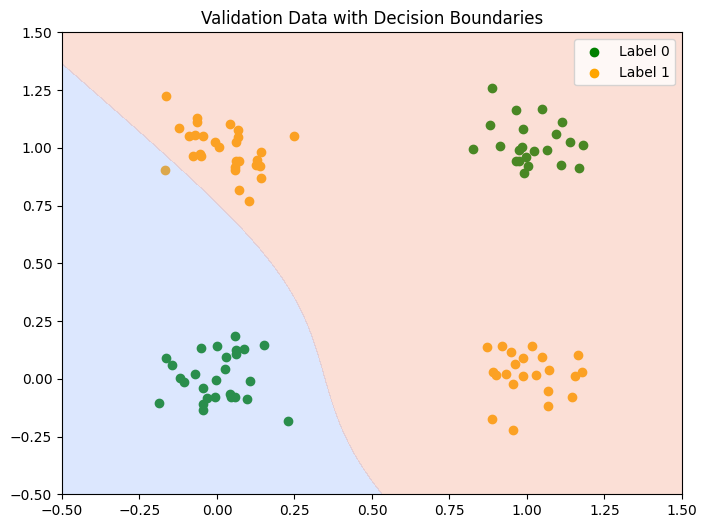

In [7]:
# Initialize model, loss, and optimizer
model = XORNet()
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
epochs = 100
for epoch in range(epochs):
    model.train()
    total_loss = 0.0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        logits = model(batch_x).squeeze()
        loss = criterion(logits, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch + 1}, Loss: {total_loss:.4f}")

# Validation and visualization
model.eval()
print("Validation data with boundaries:")
plot_data(val_data, model, title="Validation Data with Decision Boundaries")


# Different width/depth models

In [8]:
# Define the XORNet model class
class XORNet(nn.Module):
    def __init__(self, num_hidden_layers, hidden_widths):
        super(XORNet, self).__init__()
        
        layers = []
        in_features = 2
        np.random.seed(0)  # If you want to set a fixed seed for reproducibility

        
        # Randomly choose activation functions for hidden layers
        activation_functions = [nn.Sigmoid(), nn.Tanh(), nn.ReLU()]
        
        # Add hidden layers
        for i in range(num_hidden_layers):
            out_features = hidden_widths[i]
            layers.append(nn.Linear(in_features, out_features))
            activation_fn = np.random.choice(activation_functions)  # Random activation function
            layers.append(activation_fn)
            in_features = out_features  # The input for the next layer is the output of the current one
        
        # Final output layer
        layers.append(nn.Linear(in_features, 1))
        layers.append(nn.Identity())  # Output layer uses Identity activation
        
        self.model = nn.Sequential(*layers)
        
        self.initialize_weights()

    def initialize_weights(self):
        for layer in self.model:
            if isinstance(layer, nn.Linear):
                nn.init.kaiming_uniform_(layer.weight, nonlinearity='relu')
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        return self.model(x)

In [9]:
# Function to train and evaluate a model
def train_and_evaluate(model, train_loader, criterion, optimizer, epochs=100):
    model.train()
    total_loss = 0
    for epoch in range(epochs):
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            logits = model(batch_x).squeeze()
            loss = criterion(logits, batch_y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
    
    # Calculate mean and standard deviation of the loss
    return total_loss / epochs

In [12]:
# Set up different configurations of layers and widths
layer_configs = [(num_layers, [width] * num_layers) for num_layers in range(1, 4) for width in range(1, 4)]

# Initialize a dictionary to store results
results = {}

# Train and evaluate models for each configuration
for num_layers, hidden_widths in layer_configs:
    print(f"Training model with {num_layers} hidden layers and widths {hidden_widths}")
    
    # Generate dataset
    train_data = XORData(n_points=300, s=0.1)
    val_data = XORData(n_points=100, s=0.1)
    train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
    
    # Initialize model
    model = XORNet(num_layers, hidden_widths)
    
    # Initialize optimizer and loss function
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.BCEWithLogitsLoss()
    
    # Train and evaluate the model
    avg_loss = train_and_evaluate(model, train_loader, criterion, optimizer)
    
    # Store the result
    results[(num_layers, tuple(hidden_widths))] = avg_loss


# Print the results (mean and standard deviation of the loss)
for config, loss in results.items():
    print(f"Config {config}: Avg Loss = {loss}")

Training model with 1 hidden layers and widths [1]
Training model with 1 hidden layers and widths [2]
Training model with 1 hidden layers and widths [3]
Training model with 2 hidden layers and widths [1, 1]
Training model with 2 hidden layers and widths [2, 2]
Training model with 2 hidden layers and widths [3, 3]
Training model with 3 hidden layers and widths [1, 1, 1]
Training model with 3 hidden layers and widths [2, 2, 2]
Training model with 3 hidden layers and widths [3, 3, 3]
Config (1, (1,)): Avg Loss = 6.9088577055931095
Config (1, (2,)): Avg Loss = 7.164666358232498
Config (1, (3,)): Avg Loss = 7.19869687974453
Config (2, (1, 1)): Avg Loss = 6.9126382052898405
Config (2, (2, 2)): Avg Loss = 7.224967935681343
Config (2, (3, 3)): Avg Loss = 7.333724030852318
Config (3, (1, 1, 1)): Avg Loss = 6.961702711582184
Config (3, (2, 2, 2)): Avg Loss = 6.907302899956703
Config (3, (3, 3, 3)): Avg Loss = 6.903762768507004
